# Tutorial: from microelectrode recordings to decoding

A guided, runnable tour of neural spike-train analysis with **nSTAT**, written
for students. We start from what a microelectrode actually measures and end at
goodness-of-fit and decoding. Everything uses **simulated data** — no download
needed — so you can run every cell.

This notebook is the hands-on companion to the **Concepts & Background** docs
([online](https://cajigaslab.github.io/nSTAT-python/concepts/index.html)).
Citations (PMIDs) point to the [annotated bibliography](https://cajigaslab.github.io/nSTAT-python/concepts/bibliography.html).

**What you'll learn**
1. What an electrode measures: spikes vs. the local field potential (LFP).
2. Representing spikes as a point process (`nspikeTrain`).
3. The LFP and multitaper spectral analysis (`SignalObj`).
4. Fitting a point-process GLM and recovering the encoding model.
5. Checking the fit with the time-rescaling KS test.
6. Where to go next: decoding.

## 0. Setup

We use NumPy for arrays, Matplotlib for plots, and a handful of nSTAT objects.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from nstat import (
    nspikeTrain, SignalObj,
    simulate_cif_from_stimulus, fit_poisson_glm, population_time_rescale,
)
rng = np.random.default_rng(7)

## 1. What a microelectrode measures: spikes vs. the LFP

A microelectrode in brain tissue records the extracellular voltage produced by
nearby neural currents. That broadband signal separates **by frequency**
(Buzsáki, Anastassiou & Koch 2012, [PMID 22595786](https://pubmed.ncbi.nlm.nih.gov/22595786/)):

| Band | Name | Origin | Tells you |
|---|---|---|---|
| ~300 Hz–5 kHz | **Spikes** | fast action-potential currents | *when* individual neurons fire |
| ~1–300 Hz | **LFP** | summed synaptic/subthreshold currents | coordinated population activity, rhythms |

So one electrode gives **two views**: high-pass it for spikes, low-pass it for
the LFP. nSTAT models both. We treat each in turn.

## 2. Spikes as a point process

nSTAT works with **spike trains** (lists of spike times), not raw voltage —
detection and spike sorting are assumed done (see Lewicki 1998,
[PMID 10221571](https://pubmed.ncbi.nlm.nih.gov/10221571/)). Wrap spike times
in an `nspikeTrain`. Below we simulate a 2 s train and draw its raster.

40 spikes; mean rate ~ 20.0 spikes/s


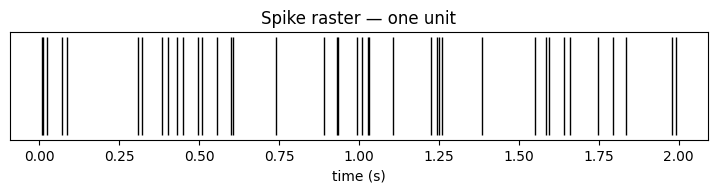

In [2]:
spike_times = np.sort(rng.uniform(0.0, 2.0, size=40))   # seconds
st = nspikeTrain(spike_times, name="unit01", sampleRate=1000,
                 minTime=0.0, maxTime=2.0)
print(f"{st.n_spikes} spikes; mean rate ~ {st.n_spikes/2.0:.1f} spikes/s")

fig, ax = plt.subplots(figsize=(9, 1.4))
ax.vlines(spike_times, 0, 1, color="k", lw=1)
ax.set(xlabel="time (s)", yticks=[], title="Spike raster — one unit")
plt.show()

A spike train looks deterministic, but repeats of the same stimulus give
different spikes. The productive view (Truccolo et al. 2005,
[PMID 15356183](https://pubmed.ncbi.nlm.nih.gov/15356183/)) is that spikes are
samples from a **point process** whose instantaneous rate — the *conditional
intensity function* (CIF) `λ(t | H_t)` — depends on the stimulus, the
neuron's own history, and the ensemble. Estimating the CIF is the job of the
GLM in Section 4.

## 3. The LFP and multitaper spectra

The LFP is the low-frequency, population part of the signal — the place to look
for **rhythms**. We simulate a toy LFP with 8 Hz (theta) and 40 Hz (gamma)
components plus noise, wrap it in a `SignalObj`, and estimate its spectrum.

The naive spectrum (periodogram) is noisy and leaks power. The **multitaper**
method (Thomson 1982; Mitra & Pesaran 1999,
[PMID 9929474](https://pubmed.ncbi.nlm.nih.gov/9929474/)) averages over
orthogonal Slepian tapers to cut variance while controlling leakage; the
time–bandwidth product `NW` sets the resolution/variance trade-off.

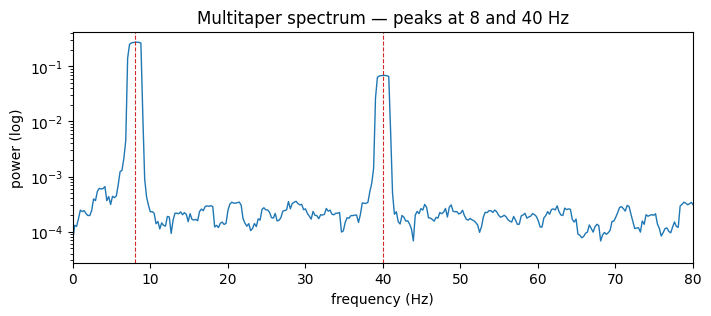

Peak frequency: 8.3 Hz


In [3]:
fs = 1000.0
t = np.arange(0.0, 4.0, 1/fs)
lfp_x = (np.sin(2*np.pi*8*t) + 0.5*np.sin(2*np.pi*40*t)
         + 0.3*rng.standard_normal(t.size))
lfp = SignalObj(t, lfp_x, name="LFP")

f, power, _ = lfp.MTMspectrum(NW=4.0)
fig, ax = plt.subplots(figsize=(8, 3))
ax.semilogy(f, power, lw=1)
ax.set(xlim=(0, 80), xlabel="frequency (Hz)", ylabel="power (log)",
       title="Multitaper spectrum — peaks at 8 and 40 Hz")
for fpk in (8, 40):
    ax.axvline(fpk, color="C3", ls="--", lw=0.8)
plt.show()
print("Peak frequency:", round(float(f[np.argmax(power)]), 1), "Hz")

Rhythms change over time. A **spectrogram** computes the spectrum in a
sliding window — power as a function of both time and frequency.

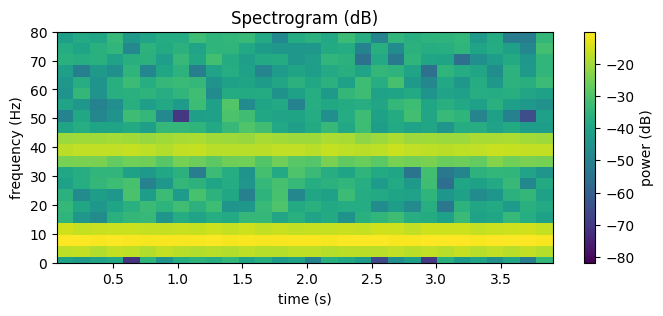

In [4]:
sf, stime, Sxx = lfp.spectrogram(nperseg=256)
fig, ax = plt.subplots(figsize=(8, 3))
m = ax.pcolormesh(stime, sf, 10*np.log10(Sxx + 1e-12), shading="auto")
ax.set(ylim=(0, 80), xlabel="time (s)", ylabel="frequency (Hz)",
       title="Spectrogram (dB)")
fig.colorbar(m, ax=ax, label="power (dB)")
plt.show()

## 4. Encoding: fit a point-process GLM

Now the core workflow. We simulate a neuron whose log-rate is driven by a 1 Hz
stimulus, `log λ(t) = β₀ + β₁·stim(t)`, then fit a Poisson GLM and
recover the parameters. The GLM log-likelihood is **concave** (Paninski 2004,
[PMID 15600233](https://pubmed.ncbi.nlm.nih.gov/15600233/)), so the fit has a
unique optimum.

In [5]:
dt = 0.001
tt = np.arange(0.0, 120.0, dt)
stim = np.sin(2*np.pi*1.0*tt)
true_b0, true_b1 = 2.5, 1.5     # ~12 Hz baseline, strong tuning

spikes, _, _ = simulate_cif_from_stimulus(time=tt, stimulus=stim,
                                          beta0=true_b0, beta1=true_b1, rng=rng)

bin_width = 0.001               # 1 ms bins (<=1 spike/bin) for time-rescaling
edges = np.arange(0.0, 120.0 + bin_width, bin_width)
y = spikes.to_binned_counts(edges)
x = stim[:, None]
offset = np.full(y.shape, np.log(bin_width))

fit = fit_poisson_glm(x, y, offset=offset, l2=1e-4, max_iter=100, tol=1e-10)
print(f"True:      beta0={true_b0:+.3f}  beta1={true_b1:+.3f}")
print(f"Estimated: beta0={fit.intercept:+.3f}  beta1={fit.coefficients[0]:+.3f}")
print(f"Converged: {fit.converged} in {fit.n_iter} iters")

True:      beta0=+2.500  beta1=+1.500
Estimated: beta0=+2.462  beta1=+1.513
Converged: True in 43 iters


## 5. Goodness-of-fit: does the model actually fit?

A good fit of parameters is not proof the model is right. The **time-rescaling
theorem** (Brown et al. 2002, [PMID 11802915](https://pubmed.ncbi.nlm.nih.gov/11802915/))
says: integrate the fitted CIF between spikes and, if the model is correct, the
rescaled intervals are unit-rate exponentials — testable with a
**Kolmogorov–Smirnov** test. `population_time_rescale` (Tao et al. 2018,
[PMID 30298220](https://pubmed.ncbi.nlm.nih.gov/30298220/)) implements it.

We contrast the **correct** model against a **wrong** constant-rate model that
matches only the mean rate.

In [6]:
lam_correct  = np.exp(fit.intercept + fit.coefficients[0]*x[:,0] + offset)
lam_constant = np.full_like(y, y.mean())   # ignores the stimulus

gof_ok   = population_time_rescale([y], [lam_correct])
gof_bad  = population_time_rescale([y], [lam_constant])
verdict = lambda p: "FITS (not rejected)" if p > 0.05 else "REJECTED"
print(f"correct  model: KS p = {gof_ok.ground_ks_pvalue:.3g}  -> {verdict(gof_ok.ground_ks_pvalue)}")
print(f"constant model: KS p = {gof_bad.ground_ks_pvalue:.3g}  -> {verdict(gof_bad.ground_ks_pvalue)}")

correct  model: KS p = 0.137  -> FITS (not rejected)
constant model: KS p = 6.59e-56  -> REJECTED


The constant-rate model is rejected even though it nails the mean rate: it
gets the *timing* wrong. **Always check goodness-of-fit**, not just parameters
or log-likelihood. For populations, `population_time_rescale` with several
neurons also catches mis-modeled inter-neuron coupling that per-neuron KS
tests miss.

## 6. Where next: decoding

We did **encoding** (stimulus → spikes) and validated it. **Decoding** inverts
it (spikes → stimulus/state) with the point-process adaptive filter
(Eden et al. 2004, [PMID 15070506](https://pubmed.ncbi.nlm.nih.gov/15070506/)) —
the spiking analogue of the Kalman filter, and the basis of brain–machine
interfaces. See **Paper Example 05** and the
[decoding concepts page](https://cajigaslab.github.io/nSTAT-python/concepts/goodness_of_fit_and_decoding.html).
When spike sorting is unreliable, **clusterless** decoding (Denovellis et al.
2021, [PMID 34570699](https://pubmed.ncbi.nlm.nih.gov/34570699/)) decodes from
spike-waveform features directly — `nstat.extras.decoding.clusterless_bridge`.

### Summary
- Microelectrodes record spikes (high-freq) and the LFP (low-freq).
- Spikes → point process; the CIF is the complete description.
- LFP → `SignalObj` multitaper spectra/spectrograms.
- Fit the CIF with a point-process GLM (`fit_poisson_glm`, `Analysis`).
- Validate with time-rescaling (`computeKSStats`, `population_time_rescale`).
- Read state back out with point-process / clusterless decoders.

**Cite:** Cajigas, Malik & Brown 2012, *J Neurosci Methods* 211:245
([PMID 22981419](https://pubmed.ncbi.nlm.nih.gov/22981419/)).